# <center> Project: classification
## <center> Predicting deposit openings

### Problem Statement

This project aims to develop a machine learning model capable of predicting whether a bank client will subscribe to a term deposit. The analysis is based on historical data from a marketing campaign carried out by a bank, with the ultimate goal of improving campaign targeting and increasing deposit conversion rates..

**Business Objective**: 
Identify the characteristics that distinguish clients who are more likely to open a bank deposit. The goal is to improve the effectiveness of the marketing campaign by targeting the right customer segments

**Technical Objective** o build a machine learning model that can predict whether a client will accept the bank's deposit offer based on the provided customer features.

## Part 1. Data exploration, handling missing values and outliers

Bank clients' data:

* age (возраст);
* job (сфера занятости);
* marital (семейное положение);
* education (уровень образования);
* default (имеется ли просроченный кредит);
* housing (имеется ли кредит на жильё);
* loan (имеется ли кредит на личные нужды);
* balance (баланс).

This group of features describes the client's last interaction during the current marketing campaign:

* contact (тип контакта с клиентом);
* month (месяц, в котором был последний контакт);
* day (день, в который был последний контакт);
* duration (продолжительность контакта в секундах).

Others features:

* campaign (количество контактов с этим клиентом в течение текущей кампании);
* pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
* previous (количество контактов до текущей кампании)
* poutcome (результат прошлой маркетинговой кампании).
И, разумеется, наша целевая переменная deposit, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
sns.set_theme(style="whitegrid", palette= "Set2", color_codes=True)
sns.set_palette(palette= "Set2",n_colors=12)
%matplotlib inline
import optuna

### Task 1

In [2]:
# read the data
df = pd.read_csv('data/bank_fin.csv', sep = ';')

In [3]:
# # Explore the dataset for missing values


df.isnull().value_counts()

age    job    marital  education  default  balance  housing  loan   contact  day    month  duration  campaign  pdays  previous  poutcome  deposit
False  False  False    False      False    False    False    False  False    False  False  False     False     False  False     False     False      11137
                                           True     False    False  False    False  False  False     False     False  False     False     False         25
Name: count, dtype: int64

**We identified 25 missing values in the 'balance' feature**

### Task 2

In [4]:
# Check if there are any missing values in the 'job' feature
# Note: missing values might be represented by a special placeholder (e.g., 'unknown')

df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

**We identified 70 missing values marked as 'unknown' in the 'job' feature**

### Task 3

In [7]:
# Convert the 'balance' feature to ensure it is properly read as a float
def float_bl(bal):
    if isinstance(bal, (int, float)):
        return bal
    bal = bal.replace(' ', '')
    bal = bal.replace('$', '')
    bal = bal.replace(',', '.')
    return float(bal)

df['balance'] = df['balance'].apply(float_bl)

display(f"Average  value of balance: {df['balance'].mean().round(3)}")

'Average  value of balance: 1529.129'

### Task 4

In [8]:
# Handle missing values in the 'balance' feature by replacing them with the median of that feature


df['balance'] = df['balance'].fillna(df['balance'].median())
display(f"Average value of balance without missing values: {df['balance'].mean().round(3)}")

'Average value of balance without missing values: 1526.936'

### Task 5

In [10]:
# Handle missing values in the categorical features 'job' and 'education' by replacing them with their respective mode values


df['education'] = df['education'].apply(lambda x: 'secondary'if x == 'unknown' else x)

df['job'] = df['job'].apply(lambda x: 'management'if x == 'unknown' else x)

mask = (df['education'] == 'secondary') & (df['job'] == 'management')

display(f"Lower bound: {df[mask]['balance'].mean().round(3)}")


'Lower bound: 1598.883'

### Task 6

In [11]:

# Remove all outliers from the 'balance' feature


def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

outliers, cleaned = outliers_iqr(df, 'balance')
print(f'The number of outliers using Tukey method: {outliers.shape[0]}')
print(f'Final number: {cleaned.shape[0]}')
IQR = df['balance'].quantile(0.75) - df['balance'].quantile(0.25)
lower_bound = df['balance'].quantile(0.25) - (IQR *1.5)
upper_bound = df['balance'].quantile(0.75) + (IQR * 1.5)
print(f'IQR: {IQR}')
print(f'Lower bound: {lower_bound}')
print(f'Uper bound: {upper_bound}')

The number of outliers using Tukey method: 1057
Final number: 10105
IQR: 1576.0
Lower bound: -2241.0
Uper bound: 4063.0


In [12]:
# Check for duplicate records in the dataset

dupl_columns = list(cleaned.columns)


mask = cleaned.duplicated(subset=dupl_columns)
df_duplicates = cleaned[mask]
print(f'Number of duplicate records found in the dataset: {df_duplicates.shape[0]}')

Number of duplicate records found in the dataset: 0


**Conclusions**: We checked the data for duplicates and missing values, removed the former and filled in the latter. As a result, we now have a preprocessed dataset ready for further analysis

## Part 2:  Exploratory Data Analysis

### Task 1

In [47]:
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        10105 non-null  int64   
 1   job        10105 non-null  object  
 2   marital    10105 non-null  object  
 3   education  10105 non-null  object  
 4   default    10105 non-null  object  
 5   balance    10105 non-null  float64 
 6   housing    10105 non-null  object  
 7   loan       10105 non-null  object  
 8   contact    10105 non-null  object  
 9   day        10105 non-null  int64   
 10  month      10105 non-null  object  
 11  duration   10105 non-null  int64   
 12  campaign   10105 non-null  int64   
 13  pdays      10105 non-null  int64   
 14  previous   10105 non-null  int64   
 15  poutcome   10105 non-null  object  
 16  deposit    10105 non-null  object  
 17  age_group  10105 non-null  category
dtypes: category(1), float64(1), int64(6), object(10)
memory usage: 1.4+ MB


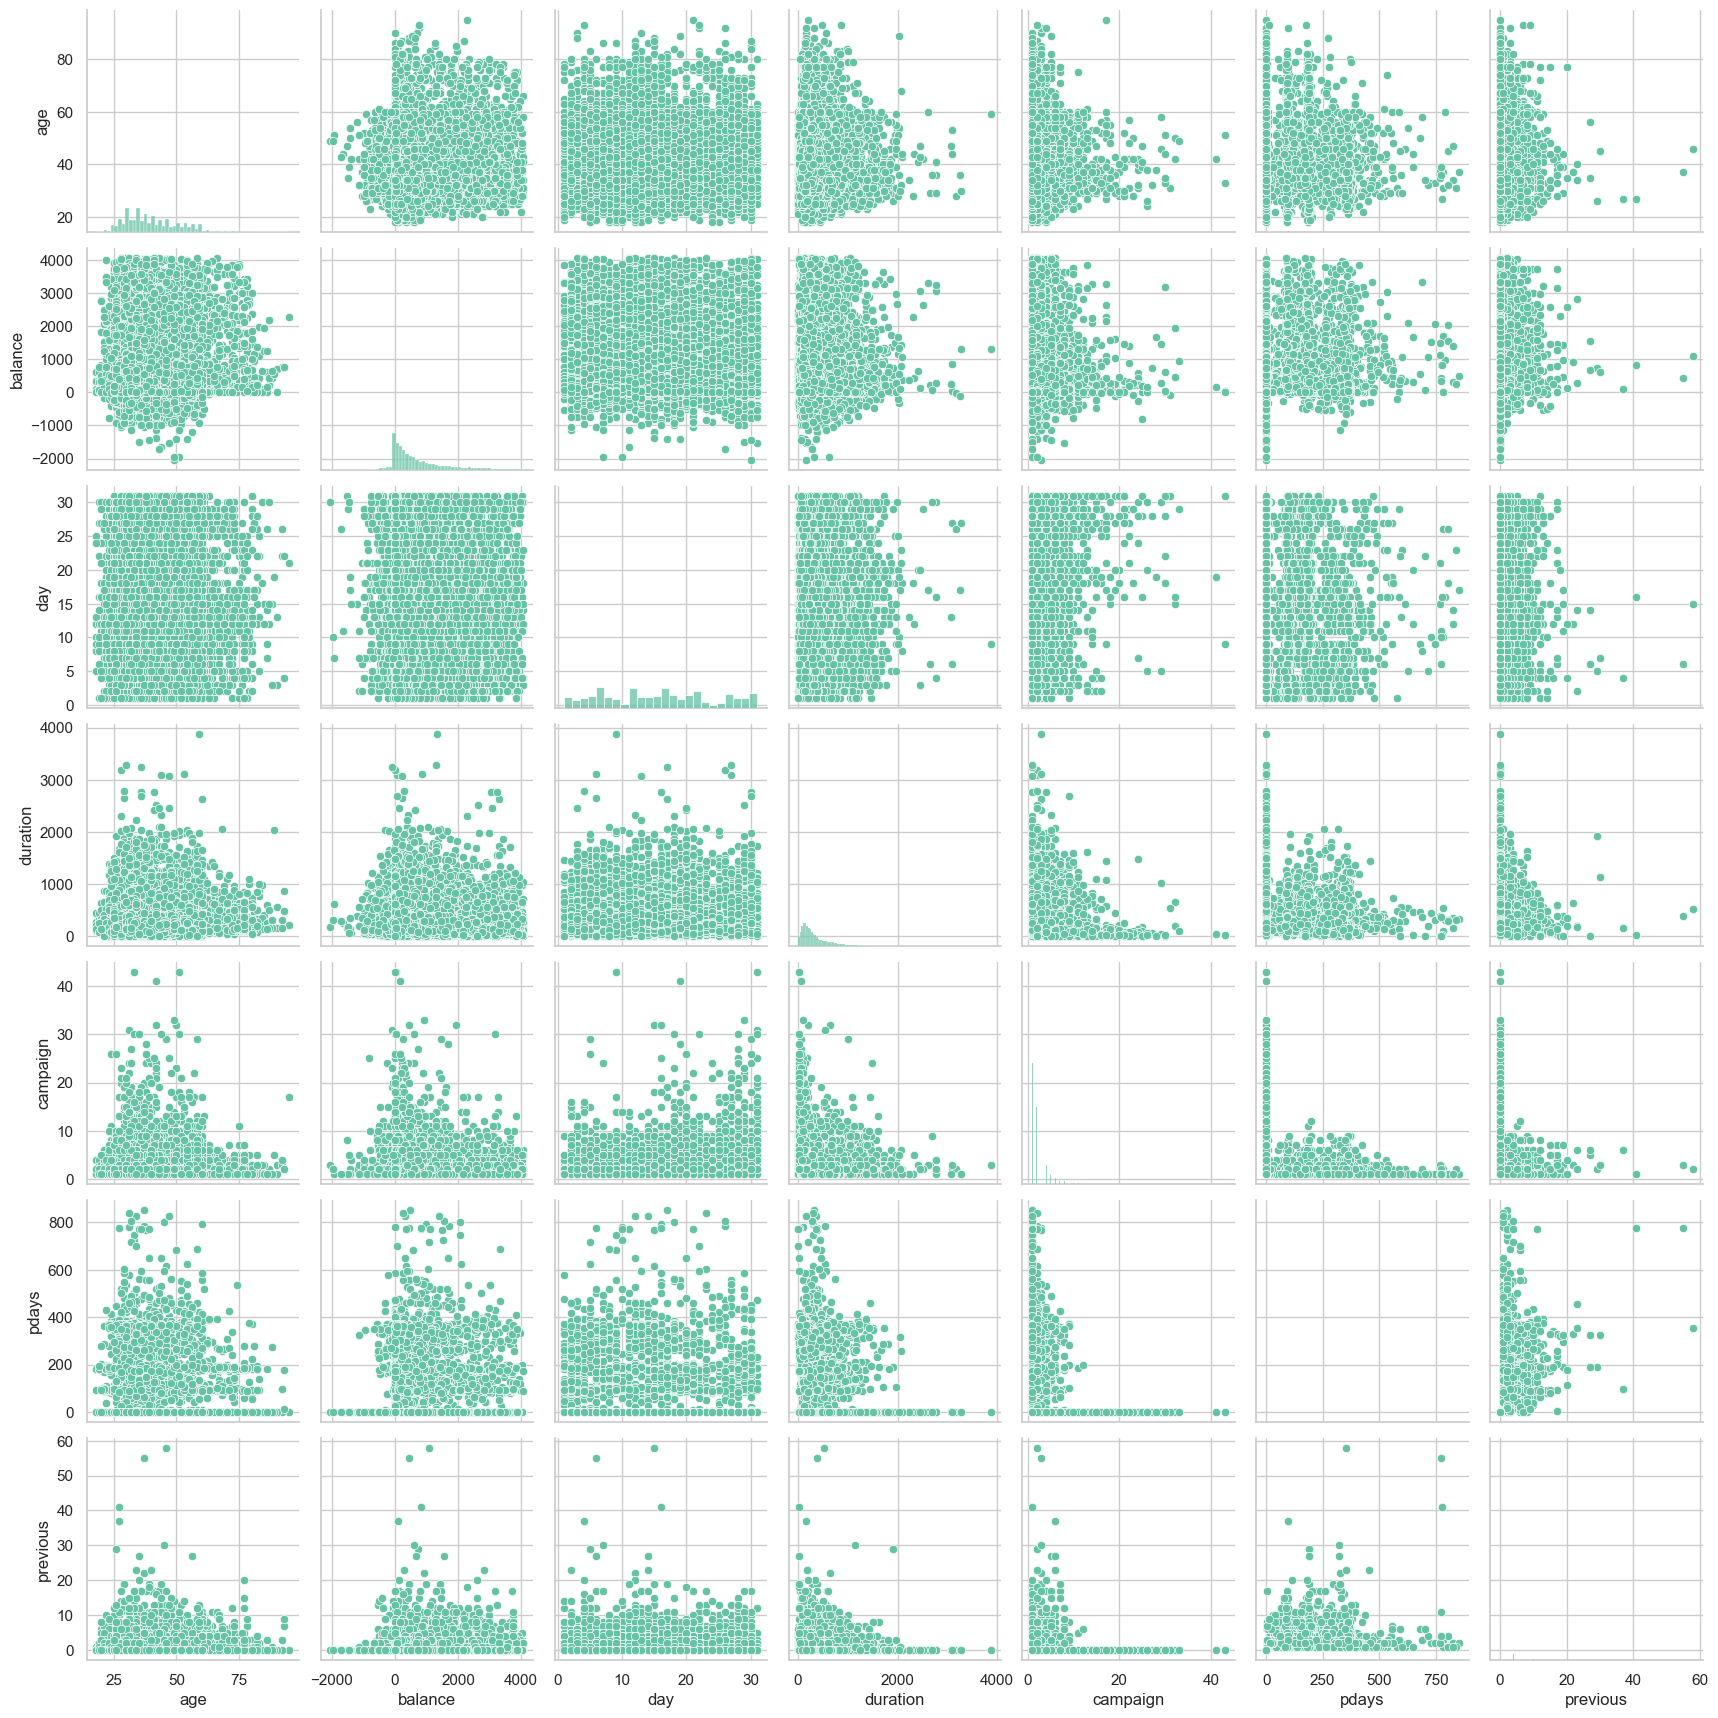

In [14]:
sns.pairplot(cleaned)

*The pairplot diagram shows the relationships between pairs of numerical features. No strong correlations are visually apparent from the plots. However, several features display clear outliers — individual data points that are noticeably separated from the main cluster*

In [13]:
# Examine the class distribution to check for imbalance and visualize the results


cleaned['deposit'].value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

<Axes: xlabel='deposit', ylabel='count'>

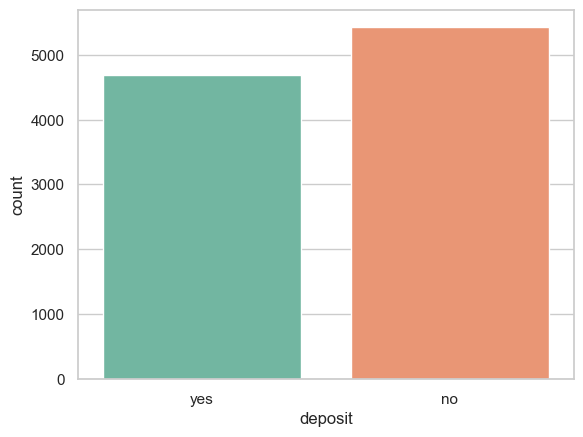

In [16]:

sns.countplot(cleaned, x="deposit", hue="deposit")

*The chart shows that after the marketing campaign, the majority of bank clients did not open a deposit*

### Задания 2 и 3

In [15]:
# Calculate descriptive statistics for numerical variables and interpret the results



cleaned['age'].describe()

count    10105.000000
mean        40.895497
std         11.734931
min         18.000000
25%         32.000000
50%         38.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

[Text(0.5, 1.0, 'Distribution of the feature "AGE"')]

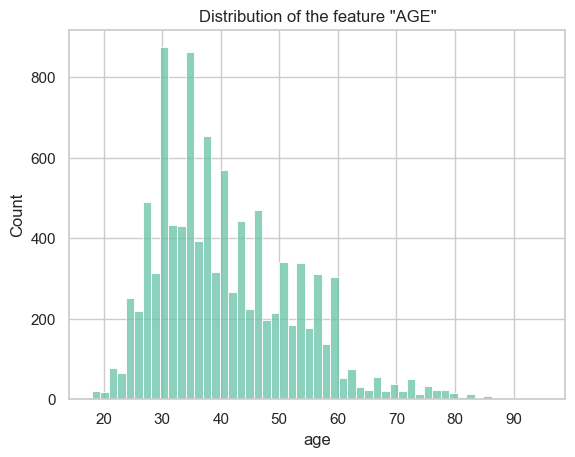

In [17]:
sns.histplot(data=cleaned, x="age").set(title = 'Distribution of the feature "AGE"')

*The average age of bank's clients is about 40. The most part of clients are from 32 to 38. The youngers is 18. The oldest is 95.*

In [18]:
cleaned['balance'].describe()

count    10105.000000
mean       807.653538
std        994.151966
min      -2049.000000
25%         95.000000
50%        445.000000
75%       1227.000000
max       4063.000000
Name: balance, dtype: float64

Text(0.5, 1.0, "Distribution of clients' balance")

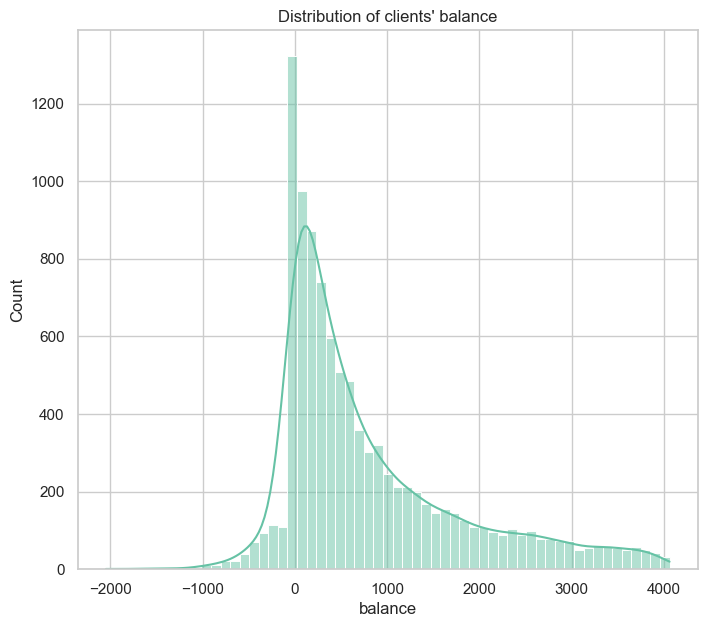

In [19]:
fig = plt.figure(figsize=(8, 7))

sns.histplot(
    data=cleaned,
    x= 'balance',
    kde=True,
    
);
plt.title(label="Distribution of clients' balance", fontsize=12)

Text(0.5, 1.0, "Distribution of clients' balance")

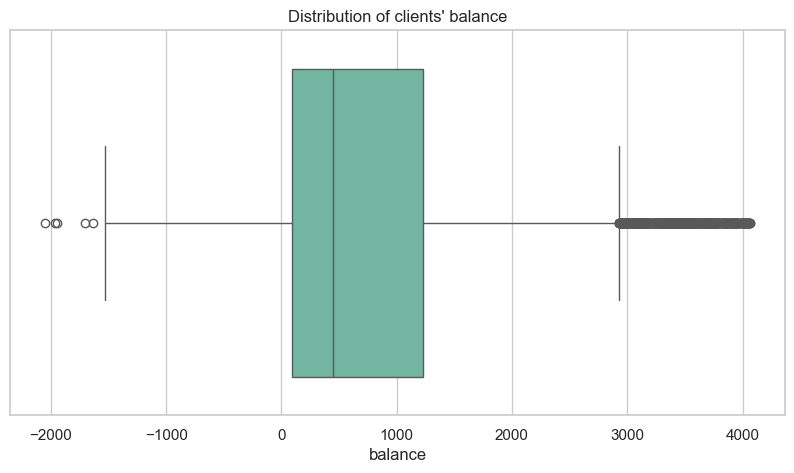

In [20]:

plt.figure(figsize=(10, 5))
sns.boxplot(x="balance", data=cleaned)
plt.title(label="Distribution of clients' balance", fontsize=12)

*The distribution of the 'balance' feature is not normal — it is right-skewed. The average client balance is approximately 807, with a minimum of -2049 and a maximum of 4063.*

In [21]:
cleaned['duration'].describe()

count    10105.000000
mean       368.742603
std        346.651524
min          2.000000
25%        137.000000
50%        252.000000
75%        490.000000
max       3881.000000
Name: duration, dtype: float64

[Text(0.5, 1.0, 'Distribution of the feature "DURATION"')]

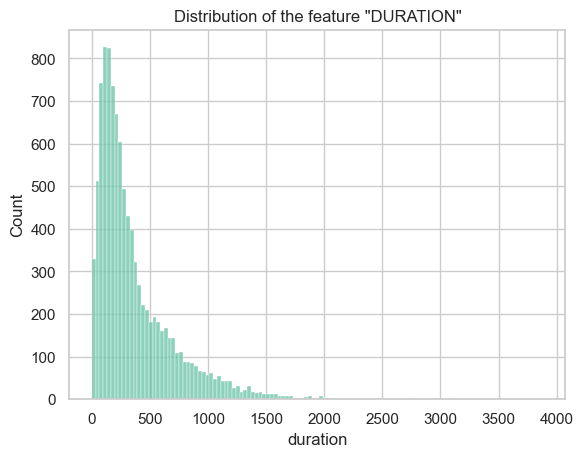

In [22]:
sns.histplot(data=cleaned, x="duration").set(title = 'Distribution of the feature "DURATION"')

*The distribution of the 'duration' feature is not normal — it is right-skewed. The average value is about 369 sec, max - 3881 sec, min - 2 sec.*

In [23]:
cleaned['previous'].describe()

count    10105.000000
mean         0.816230
std          2.243795
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         58.000000
Name: previous, dtype: float64

[Text(0.5, 1.0, 'Distribution of the feature "PREVIOUS"')]

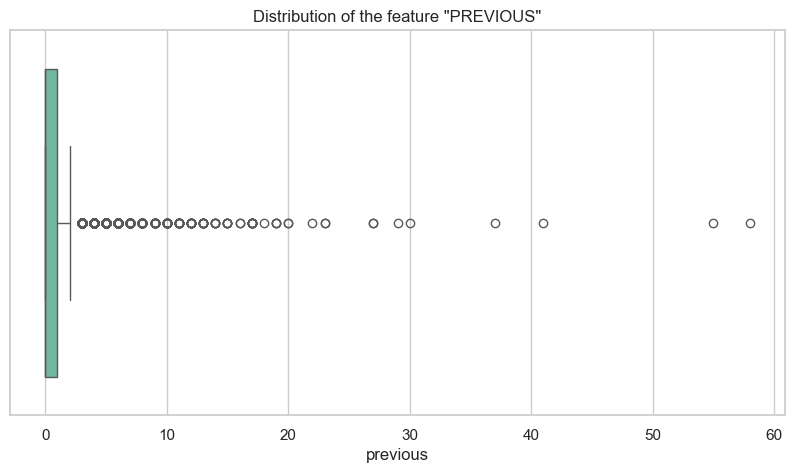

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned, x="previous").set(title = 'Distribution of the feature "PREVIOUS"')

*The 'previous' feature has a value close to 0 in most cases. This may indicate that the feature is not particularly important for our classification task.*

### Tasks 4 и 5

In [27]:
# Calculate descriptive statistics for categorical variables and interpret the results


# Create visualizations to illustrate the distribution and frequency of categorical features


In [48]:
cleaned.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,10105,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570,5424


In [32]:
cleaned['job'].describe(include='object')

count          10105
unique            11
top       management
freq            2315
Name: job, dtype: object

Text(0.5, 1.0, 'Distribution of the "JOB" feature among bank clients ')

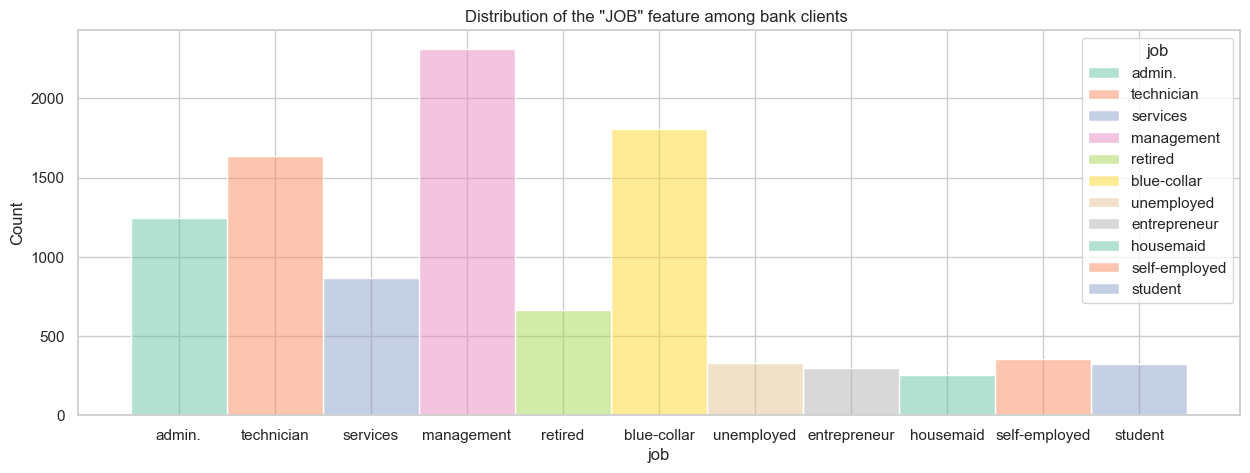

In [26]:
plt.figure(figsize=(15, 5))
sns.histplot(data=cleaned, x="job", hue="job")
plt.title(label='Distribution of the "JOB" feature among bank clients ', fontsize=12)

*As mentioned above, most of the bank’s clients are employed as managers, followed by blue-collar workers. The smallest group is housemaid*

In [ ]:
cleaned['month'].describe(include='object')

count     10105
unique       12
top         may
freq       2617
Name: month, dtype: object

Text(0.5, 1.0, 'Distribution of the "MONTH" feature among bank clients')

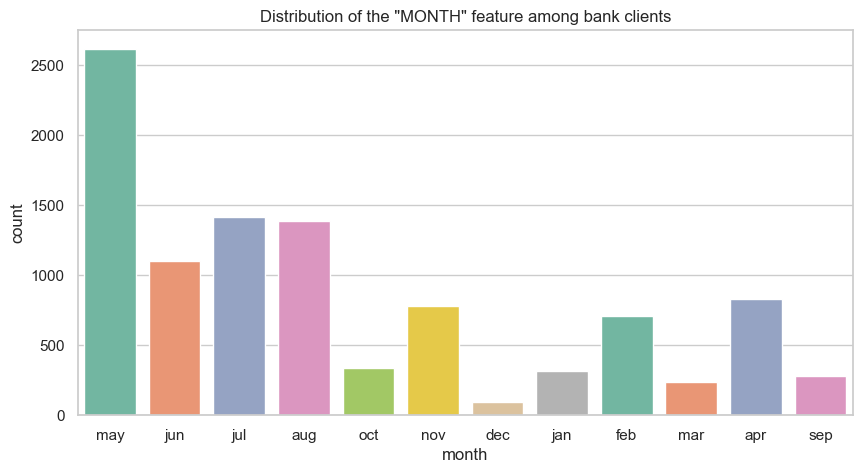

In [27]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned, x="month", hue="month")
plt.title(label='Distribution of the "MONTH" feature among bank clients', fontsize=12)

*The diagram shows that the marketing campaign was conducted throughout the entire year. May had the highest number of participants, while December had the lowest.*

Text(0.5, 1.0, 'Distribution of the "MARITAL" feature among bank clients')

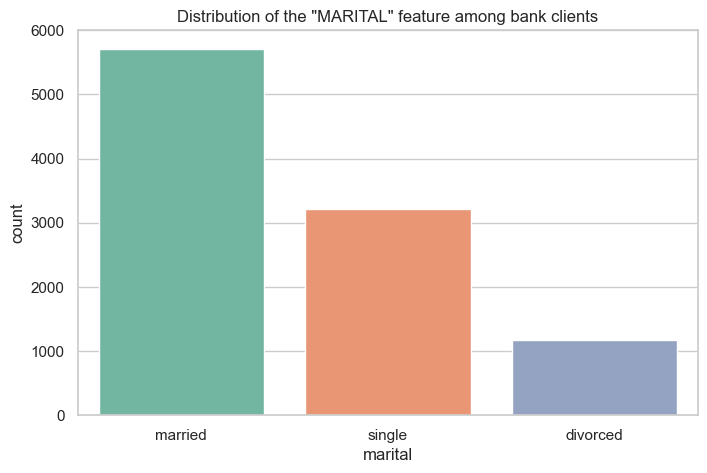

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=cleaned, x="marital", hue="marital")
plt.title(label='Distribution of the "MARITAL" feature among bank clients', fontsize=12)

*Most of the bank’s clients are married, while divorced clients make up the smallest group.*

Text(0.5, 1.0, 'Distribution of the "EDUCATION" feature among bank clients')

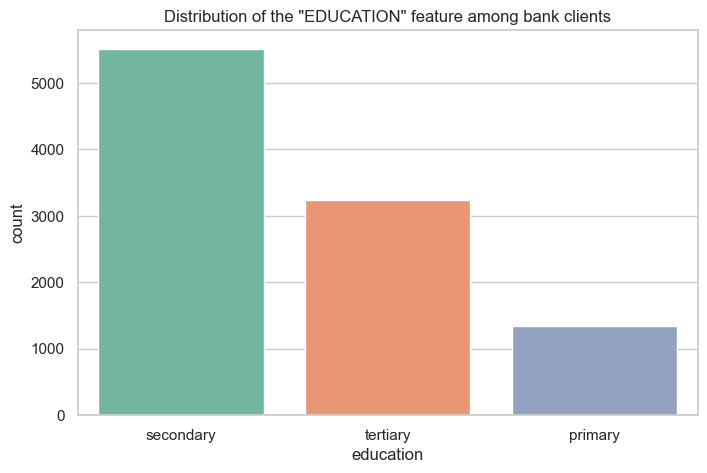

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=cleaned, x="education", hue="education")
plt.title(label='Distribution of the "EDUCATION" feature among bank clients', fontsize=12)

*The majority of the bank’s clients have a secondary level of education.*

Text(0.5, 1.0, 'Distribution of the "CONTACT" feature among bank clients')

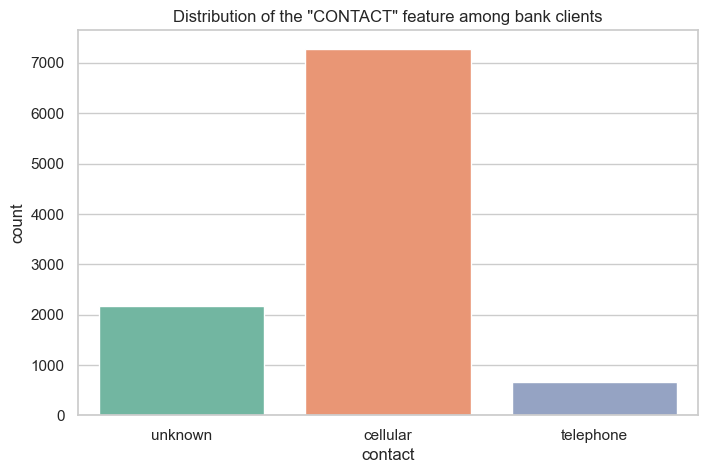

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(data=cleaned, x="contact", hue="contact")
plt.title(label='Distribution of the "CONTACT" feature among bank clients', fontsize=12)

*Most client interactions during the marketing campaign were made via mobile phone calls.*

### Task 6

In [37]:
# # Identify which outcome of the previous marketing campaign is associated with more successes than failures in the current campaign


df_grouped = cleaned.groupby(cleaned['poutcome'])['deposit'].value_counts(normalize=False).unstack()
df_grouped

deposit,no,yes
poutcome,,
failure,562,547
other,216,265
success,84,861
unknown,4562,3008


*The highest success rate in the current marketing campaign is observed among clients whose status in the previous campaign was marked as 'success'.*


### Task 7

In [36]:
# Determine in which month clients most frequently declined the offer to open a deposit

In [35]:
# Создадим словарь для хранения результатов
decline_ratio_by_month = {}

# Получим уникальные значения месяцев
months = cleaned['month'].unique()

for month in months:
    total = len(cleaned[cleaned['month'] == month])
    declined = len(cleaned[(cleaned['month'] == month) & (cleaned['deposit'] == 'no')])
    
    ratio = declined / total if total > 0 else 0
    decline_ratio_by_month[month] = round(ratio, 3)  # округлим для читаемости

# Преобразуем в DataFrame для удобства просмотра или визуализации
import pandas as pd

decline_ratio_df = pd.DataFrame.from_dict(decline_ratio_by_month, orient='index', columns=['decline_ratio'])
decline_ratio_df = decline_ratio_df.sort_values(by='decline_ratio', ascending=False)

print(decline_ratio_df)

     decline_ratio
may          0.679
jan          0.608
jul          0.590
nov          0.585
aug          0.560
jun          0.549
feb          0.456
apr          0.382
oct          0.185
sep          0.165
mar          0.101
dec          0.097


<Figure size 1000x600 with 0 Axes>

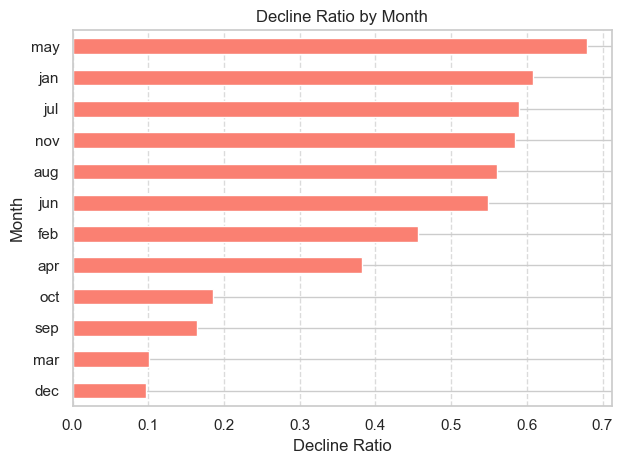

In [37]:
plt.figure(figsize=(10, 6))
decline_ratio_df.plot(kind='barh', legend=False, color='salmon')

plt.title('Decline Ratio by Month')
plt.xlabel('Decline Ratio')
plt.ylabel('Month')
plt.gca().invert_yaxis()  # Чтобы самый высокий был сверху
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

*The highest failure rate occurred in May, while the lowest was in December. This may indicate that May is not the most effective month for running a marketing campaign.*

### Task 8

Text(0.5, 1.0, 'Relationship between deposit subscription and age')

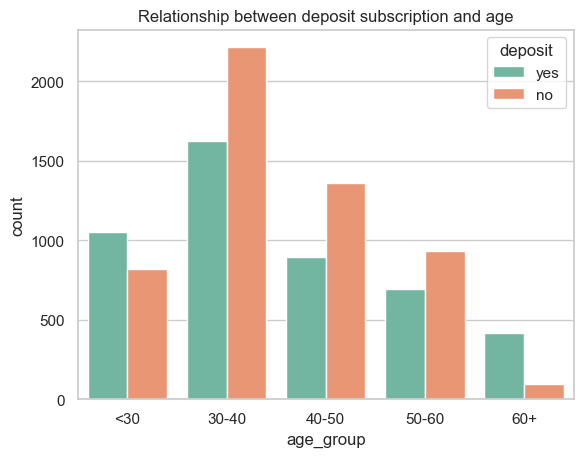

In [49]:
# # Create age groups and identify which groups are more likely to open a deposit than to decline the offer

cleaned['age_group'] = pd.cut(cleaned.age, [0,30,40,50,60,9999], labels = ['<30','30-40','40-50','50-60','60+'])
sns.countplot(x="age_group", hue="deposit", data=cleaned)
plt.title(label='Relationship between deposit subscription and age', fontsize=12)

*People under the age of 30 and over 60 tend to open a deposit after receiving a marketing offer.*

### Tasks 9 and 10

Text(0.5, 1.0, 'Relationship between deposit subscription and marital status')

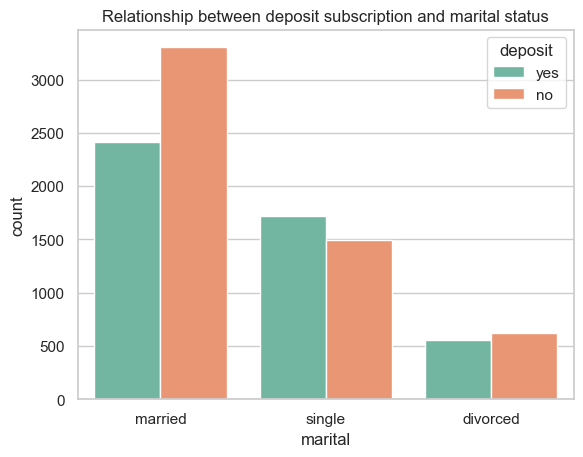

In [50]:
# # Create visualizations showing the relationship between marital status and deposit subscription (opened vs. not opened)

sns.countplot(x="marital", hue="deposit", data=cleaned)
plt.title(label='Relationship between deposit subscription and marital status', fontsize=12)

*Single clients are more likely to respond positively to a deposit offer after a marketing campaign.*

Text(0.5, 1.0, 'Relationship between deposit subscription and education')

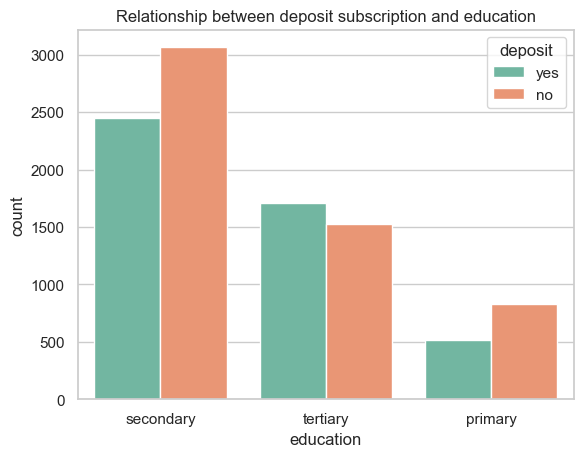

In [51]:
# Create visualizations showing the relationship between education level and deposit subscription (opened vs. not opened)

sns.countplot(x="education", hue="deposit", data=cleaned)
plt.title(label='Relationship between deposit subscription and education', fontsize=12)

*Clients with tertiary education are more likely to respond positively to a deposit offer after a marketing campaign.*

Text(0.5, 1.0, 'Relationship between deposit subscription and type of employment')

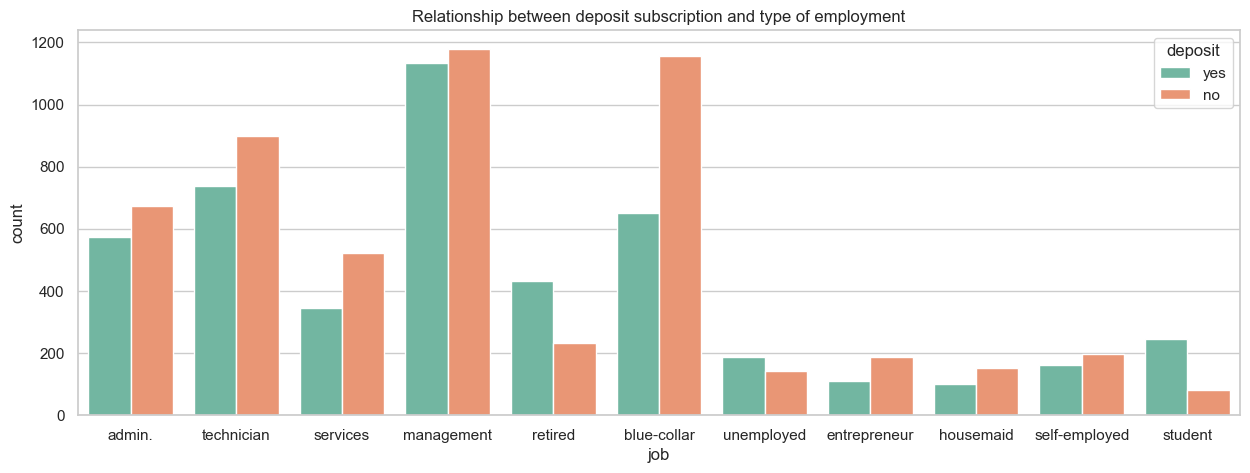

In [41]:
# Create visualizations showing the relationship between job type and deposit subscription (opened vs. not opened)

plt.figure(figsize=(15, 5))
sns.countplot(x="job", hue="deposit", data=cleaned)
plt.title(label='Relationship between deposit subscription and type of employment', fontsize=12)

*Retired, unemployed and student clients tend to open a deposit after receiving a marketing offer.*

### Task 11

In [52]:
cleaned['education'].describe()

count         10105
unique            3
top       secondary
freq           5517
Name: education, dtype: object

In [53]:

mask_no = cleaned['deposit'] == 'no'
mask_yes = cleaned['deposit'] == 'yes'

df_no = cleaned[mask_no]
df_yes = cleaned[mask_yes]


In [54]:
df_yes['education'].describe()

count          4681
unique            3
top       secondary
freq           2451
Name: education, dtype: object

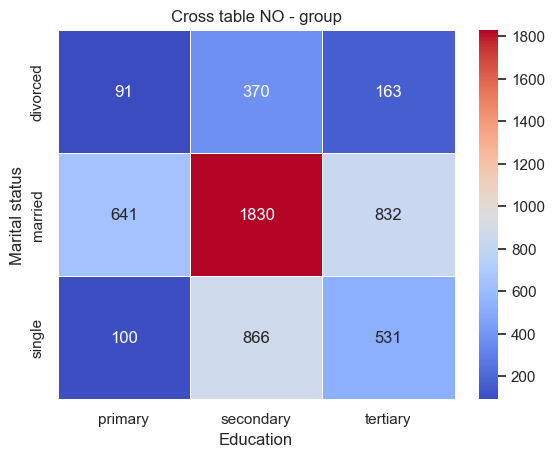

In [55]:
# Create a pivot table to identify which combinations of education level and marital status are most common among clients who opened a deposit




# Create a crosstab
cross_tab_1 = pd.crosstab(index=df_no['marital'], columns=df_no['education'])

# create a plot
ax = sns.heatmap(cross_tab_1, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel='Education', ylabel='Marital status')
plt.title('Cross table NO - group')
plt.show()


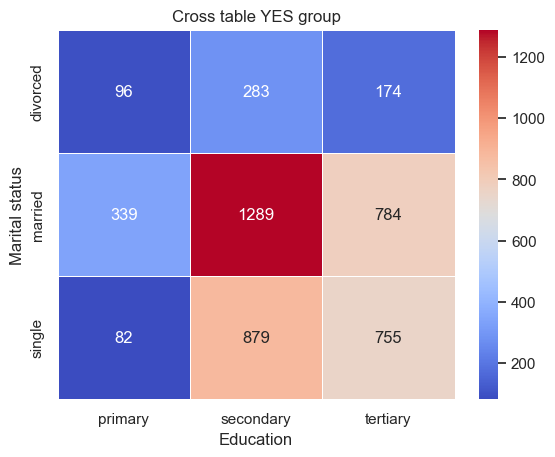

In [56]:
# Create a contingency table (cross-tabulation)
cross_tab_1 = pd.crosstab(index=df_yes['marital'], columns=df_yes['education'])

# строим график
ax = sns.heatmap(cross_tab_1, annot=True, linewidth=.5, fmt='.0f', cmap="coolwarm")
ax.set(xlabel='Education', ylabel='Marital status')
plt.title('Cross table YES group')
plt.show()

*The largest groups among the bank’s clients are married individuals with secondary education. However, other groups showed a stronger tendency to respond positively to the marketing campaign*

## Part 3: Feature Engineering

In [57]:
df_1 = cleaned.copy()

In [58]:
df_1.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,59,admin.,married,secondary,no,2343.0,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,50-60
1,56,admin.,married,secondary,no,45.0,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,50-60
2,41,technician,married,secondary,no,1270.0,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,40-50
3,55,services,married,secondary,no,2476.0,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,50-60
4,54,admin.,married,tertiary,no,184.0,no,no,unknown,5,may,673,2,-1,0,unknown,yes,50-60


### Task 1

In [65]:
# Transform the education levels to consolidate or simplify categories

le = LabelEncoder()
df_1['education'] = le.fit_transform(df_1['education'])


df.head()
display(f"Sum of education encoded feature: {df_1['education'].sum()}")


'Sum of education encoded feature: 11995'

### Task 2 and 3

In [60]:
# Transform the age to consolidate or simplify categories


le = LabelEncoder()
df_1['age_group'] = le.fit_transform(df_1['age_group'])

df_1['age_group'].describe()

count    10105.000000
mean         1.437308
std          1.489490
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: age_group, dtype: float64

In [61]:
# Convert binary categorical variables to numerical format using 0 and 1


lb = LabelBinarizer()
df_1['deposit'] = lb.fit_transform(df_1['deposit'])
df_1['deposit'].std().round(3)



0.499

In [62]:
df_1['housing'] = lb.fit_transform(df_1['housing'])
df_1['loan'] = lb.fit_transform(df_1['loan'])
df_1['default'] = lb.fit_transform(df_1['default'])

df_1.head()
print(round((df_1['housing'].mean() + df_1['loan'].mean() + df_1['default'].mean()), 3))

0.635


### Task 4

In [63]:
# Create dummy variables for categorical features

df_1 = pd.get_dummies(df_1, prefix=['job', 'marital', 'contact', 'month', 'poutcome'], dtype=int)



In [64]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   education          10105 non-null  int32  
 2   default            10105 non-null  int32  
 3   balance            10105 non-null  float64
 4   housing            10105 non-null  int32  
 5   loan               10105 non-null  int32  
 6   day                10105 non-null  int64  
 7   duration           10105 non-null  int64  
 8   campaign           10105 non-null  int64  
 9   pdays              10105 non-null  int64  
 10  previous           10105 non-null  int64  
 11  deposit            10105 non-null  int32  
 12  age_group          10105 non-null  int32  
 13  job_admin.         10105 non-null  int32  
 14  job_blue-collar    10105 non-null  int32  
 15  job_entrepreneur   10105 non-null  int32  
 16  job_housemaid      10105 no

In [66]:
# Remove irrelevant features from the dataset

df_1 = df_1.drop('age', axis=1)


### Tasks 5 and 6

<Axes: >

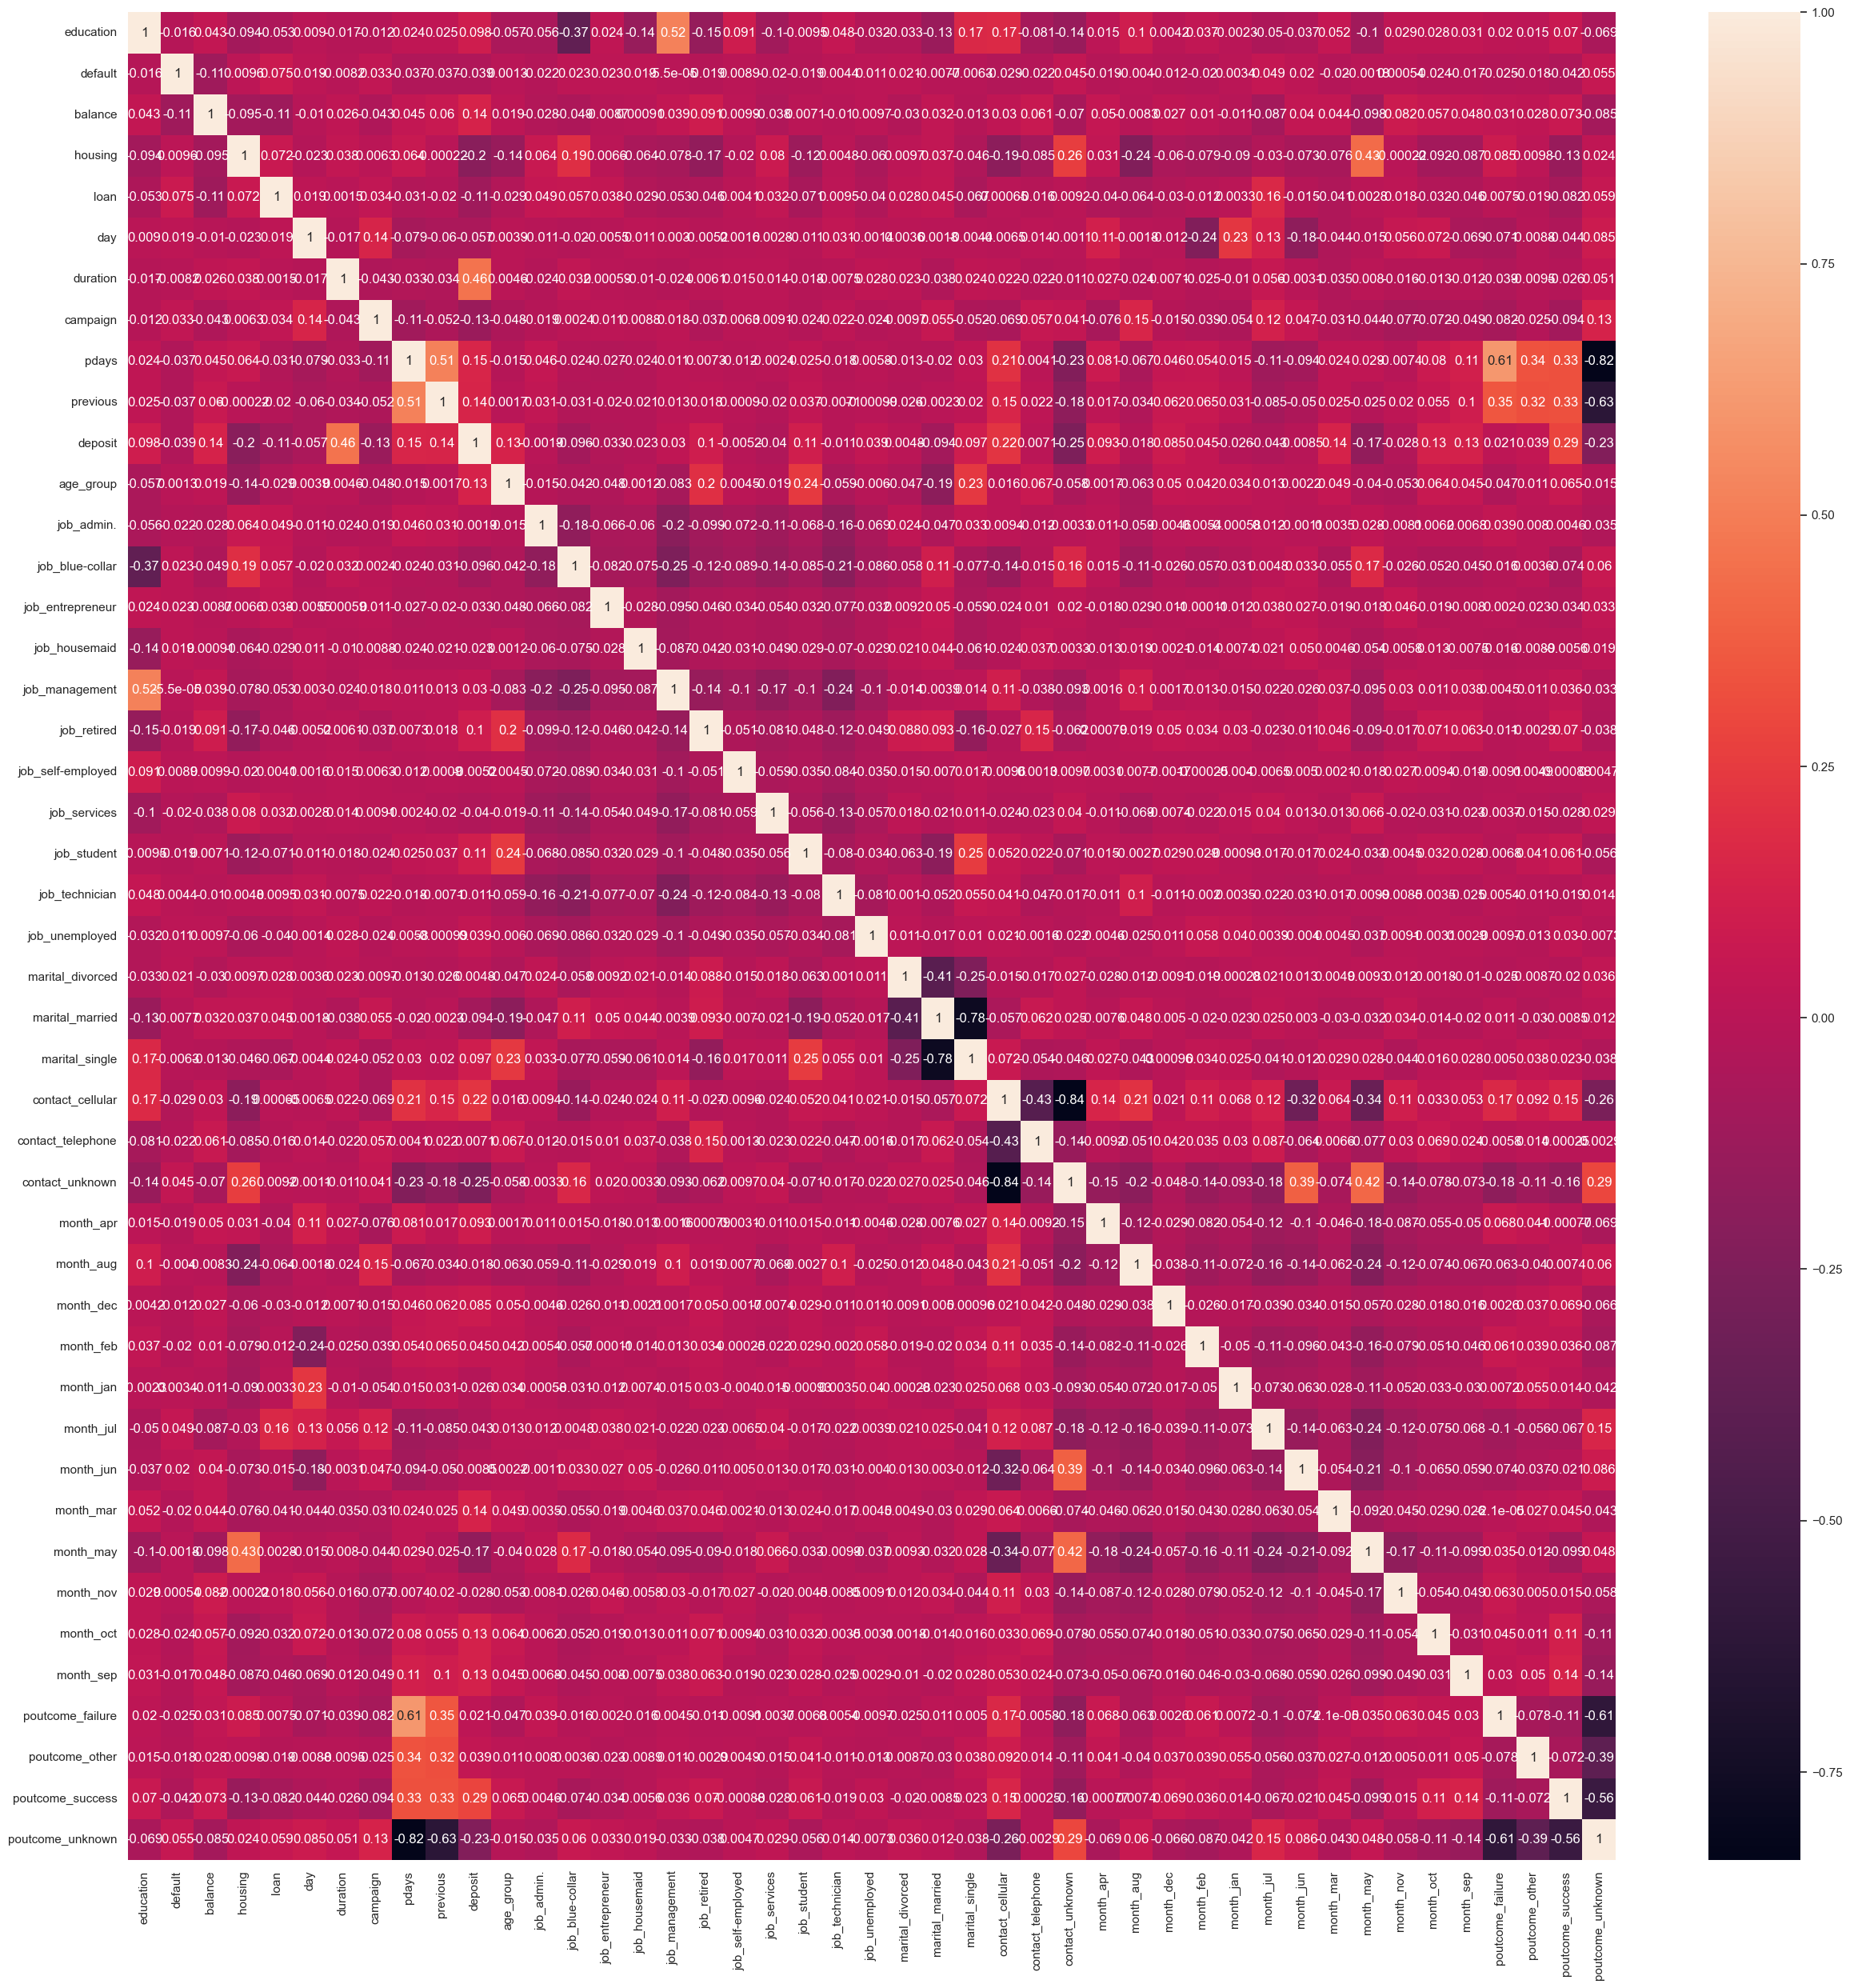

In [67]:
# # Visualize the correlation matrix to detect highly correlated features that may indicate multicollinearity

plt.figure(figsize=(30, 30))
sns.heatmap(df_1.corr(), annot=True)

*There are no features in the dataset with strong correlation above 0.9.*

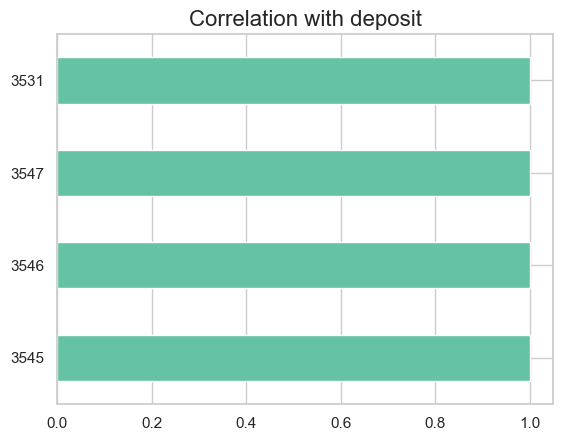

In [321]:
df_1["deposit"].apply(lambda x: abs(x)).sort_values()[-5:-1].plot.barh()
plt.title("Correlation with deposit", fontsize = 16)
plt.show()

### Tasks 7 and 8

In [69]:
# separate the data into features (X) and the target label (y)
X = df_1.drop(['deposit'], axis=1)
y = df_1['deposit']

# split into training and test data 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [70]:
# Calculate the necessary metrics
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))
print('Mean Y: {}'.format(y.mean().round(2)))

Train shape: (6770, 44)
Test shape: (3335, 44)
Mean Y: 0.46


### Task 9

In [110]:
# Use SelectKBest to select the top 15 most relevant features

selector_1 = SelectKBest(f_classif, k=15)
selector_1.fit(X_train, y_train)
 
selector_1.get_feature_names_out()

array(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_group', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

In [111]:
# Selected features for the training and test data
X_train_selected = selector_1.transform(X_train)
X_test_selected = selector_1.transform(X_test)

### Задание 10

In [112]:
# Normalize the data using MinMaxScaler

scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train_selected)                           # fit() only for train data
X_train_scaled = scaler.transform(X_train_selected)    # fransform() for train data
X_test_scaled = scaler.transform(X_test_selected)      # fransform() for test data

print(round((X_test_scaled[:, 0].mean()),2)) 

0.47


# Part 4: Solving a Classification Problem: Logistic Regression and Decision Trees

### Task 1

In [113]:
# Fit a logistic regression model and evaluate its performance using relevant metrics

#Initialize the Logistic Regression model
log_reg = linear_model.LogisticRegression(
    solver='sag', 
    random_state=42, 
    max_iter=1000 
)
# Fit the model with log loss as the objective function
log_reg.fit(X_train_scaled, y_train)
print("accuracy: {:.2f}".format(log_reg.score(X_test_scaled, y_test)))
y_test_pred = log_reg.predict(X_test_scaled)
print('f1_score: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

accuracy: 0.81
f1_score: 0.78


### Tasks 2,3,4

In [114]:
# Fit decision tree models and set the maximum depth parameter

#Initialize the DecisionTreeClassifier model
dt_= tree.DecisionTreeClassifier(
    criterion='entropy', 
    random_state=42
)
#Fit the model using the CART algorithm
dt_.fit(X_train_scaled, y_train)

y_test_pred = dt_.predict(X_test_scaled)
#Print the classification report with performance metrics
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.77      0.77      1790
           1       0.73      0.72      0.73      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.75      0.75      3335
weighted avg       0.75      0.75      0.75      3335



In [115]:
dt_1= tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth = 6
)

dt_1.fit(X_train_scaled, y_train)

print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.77      0.77      1790
           1       0.73      0.72      0.73      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.75      0.75      3335
weighted avg       0.75      0.75      0.75      3335



**Conclusion:**  
Three machine learning models were developed to solve the classification task. Their performance on the test dataset is summarized below
* LogisticRegression accuracy: 0.81, f1_score: 0.78
* DecisionTreeClassifier accuracy: 0.75, f1_score: 0.73
* DecisionTreeClassifier(max_depth = 6): accuracy: 0.75, f1_score: 0.73

### Task 5

In [116]:
# Select the optimal parameters using GridSearch
from sklearn.model_selection import GridSearchCV

param_grid = {'min_samples_leaf': [2, 5, 7, 10], # Minimum number of samples in a leaf
              'max_depth': list(np.linspace(3, 5, 7, dtype=int)), #Maximum depth of the decision trees
              }
grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(),
    param_grid=param_grid, 
    cv=5, 
    n_jobs = -1
)  
%time grid_search.fit(X_train_scaled, y_train) 
print("accuracy of test data: {:.2f}".format(grid_search.score(X_test_scaled, y_test)))
y_test_pred = grid_search.predict(X_test_scaled)
print('f1_score of test data: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("The best parameters: {}".format(grid_search.best_params_))

CPU times: total: 594 ms
Wall time: 6.21 s
accuracy of test data: 0.78
f1_score of test data: 0.79
The best parameters: {'max_depth': 5, 'min_samples_leaf': 7}


**Conclusion:**

Using GridSearchCV, we determined that the optimal hyperparameters for the DecisionTreeClassifier model are: max_depth = 5 and min_samples_leaf = 7.

# Part 5: Solving a Classification Problem: Model Ensembles and Making Predictions

### Task 1

In [117]:
# Train a Random Forest on your data

#Initialize the Random Forest model with the best parameters
rf = ensemble.RandomForestClassifier(
    n_estimators = 100,
    criterion = 'gini',
    min_samples_leaf = 5,
    max_depth = 10,
    random_state=42)
#Fil the model
rf.fit(X_train_scaled, y_train)
#Print the evaluation metric results 
y_train_pred = rf.predict(X_train_scaled)
#print('Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
y_test_pred = rf.predict(X_test_scaled)
#print('Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Tasks 2 and 3

In [118]:
# Use gradient boosting for classification and compare its performance to that of the random forest

gb = ensemble.GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
gb.fit(X_train_scaled, y_train)

y_test_pred= gb.predict(X_test_scaled)

print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



**Conclusion: Both models — random forest and gradient boosting — achieved comparable results.**
* random forest: accuracy of test data - 0.83
* gradient boosting: accuracy of test data - 0.83

### Task 4

In [119]:
# Use stacking to combine the models you’ve already learned

estimators = [
    ('dt', tree.DecisionTreeClassifier(
        criterion='entropy',
        min_samples_leaf=7,
        max_depth=5,
        random_state=42
        )
    ),
    ('log_reg', linear_model.LogisticRegression(
        solver='sag',
        random_state=42 
        )
    ),
    ('gb', ensemble.GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
        )
    )
]

stack = ensemble.StackingClassifier(
    estimators,
    final_estimator=linear_model.LogisticRegression(random_state=42)
)
stack.fit(X_train_scaled, y_train)

y_test_pred_st=stack.predict(X_test_scaled)

print(metrics.classification_report(y_test, y_test_pred_st))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1790
           1       0.81      0.82      0.81      1545

    accuracy                           0.83      3335
   macro avg       0.82      0.83      0.82      3335
weighted avg       0.83      0.83      0.83      3335



**We combined the Random  Logistic Regression, Forest and Gradient Boosting models into a StackingClassifier, which achieved the following results::  accuracy: 0.82, f1-score: 0.81**

### Task 5

In [120]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import RFE

# Assess which features are the most important according to the gradient boosting model
selected_columns = X_train.columns[:X_train_scaled.shape[1]]  
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_columns)

# Updated classifier
estimator = tree.DecisionTreeClassifier(
        criterion='entropy',
        min_samples_leaf=7,
        max_depth=5,
        random_state=42
        )
# RFE configuration
selector = RFE(estimator, n_features_to_select=3, step=1)
selector = selector.fit(X_train_scaled, y_train)


important_features = X_train_scaled.columns[selector.support_]
print("The most important features:", important_features)

The most important features: Index(['balance', 'pdays', 'job_entrepreneur'], dtype='object')


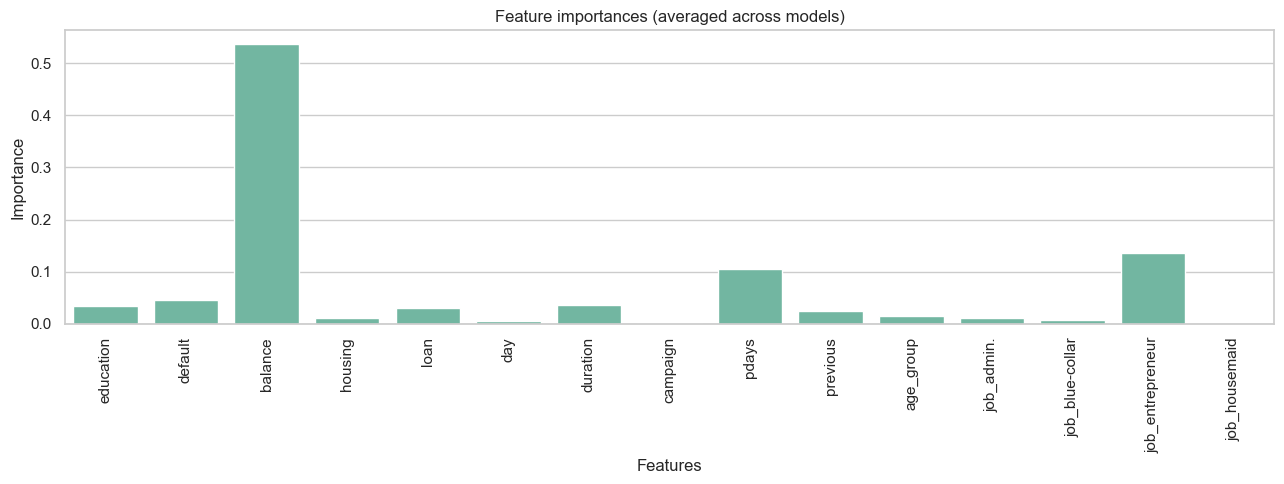

In [93]:
importances = []
for name, model in stack.named_estimators_.items():
    if hasattr(model, "feature_importances_"):
        importances.append(model.feature_importances_)


avg_importances = np.mean(importances, axis=0)


fig, ax = plt.subplots(figsize=(13, 5))

feature_names = X_train_scaled.columns
sns.barplot(x=feature_names, y=avg_importances, ax=ax)

ax.set_title('Feature importances (averaged across models)')
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The most important features: balance, pdayss, job_entrepreneur

### Tasks 6,7,8

In [87]:
# Perform hyperparameter optimization using Optuna
random_state = 42
def optuna_rf(trial):
  # Define the hyperparameter search space
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  # Initialize the model
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=random_state)
  # fit the model
  model.fit(X_train_scaled, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train_scaled))

  return score


In [96]:
%%time
# Create a study object
# We can explicitly specify that we want to maximize the metric using direction='maximize'
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
#Search for the best combination of hyperparameters for n_trials iterations
study.optimize(optuna_rf, n_trials=20)

[I 2025-07-23 19:24:27,030] A new study created in memory with name: RandomForestClassifier
[I 2025-07-23 19:24:27,984] Trial 0 finished with value: 0.8585685326680181 and parameters: {'n_estimators': 126, 'max_depth': 20, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8585685326680181.
[I 2025-07-23 19:24:29,036] Trial 1 finished with value: 0.8585229043315674 and parameters: {'n_estimators': 138, 'max_depth': 27, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.8585685326680181.
[I 2025-07-23 19:24:29,926] Trial 2 finished with value: 0.8433129027188433 and parameters: {'n_estimators': 123, 'max_depth': 11, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8585685326680181.
[I 2025-07-23 19:24:31,883] Trial 3 finished with value: 0.85875 and parameters: {'n_estimators': 197, 'max_depth': 13, 'min_samples_leaf': 6}. Best is trial 3 with value: 0.85875.
[I 2025-07-23 19:24:33,785] Trial 4 finished with value: 0.8565637667602122 and parameters: {'n_estimators': 173, 'max

CPU times: total: 28.9 s
Wall time: 30.1 s


In [97]:
# calculate the accuracy for the test data
model = ensemble.RandomForestClassifier(**study.best_params,random_state=random_state, )
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
print("accuracy of train data: {:.2f}".format(model.score(X_test_scaled, y_test)))
y_test_pred = model.predict(X_test_scaled)
print('f1_score of test data: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

accuracy of train data: 0.83
f1_score of test data: 0.82


In [98]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1790
           1       0.80      0.84      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



## Conclusion
The machine learning models were developed to solve the classification task. Their performance on the test dataset is summarized below
* LogisticRegression accuracy: 0.81, f1_score: 0.78
* DecisionTreeClassifier accuracy: 0.75, f1_score: 0.73
* DecisionTreeClassifier(max_depth = 6): accuracy: 0.75, f1_score: 0.73
* Using GridSearchCV, we determined that the optimal hyperparameters for the DecisionTreeClassifier model are: max_depth = 5 and min_samples_leaf = 7.
* random forest: accuracy of test data - 0.83
* gradient boosting: accuracy of test data - 0.83
* StackingClassifier, which achieved the following results::  accuracy: 0.82, f1-score: 0.81
* optuna RandomForestClassifier accuracy : 0.83 f1_score: 0.82

The best results were achieved by the RandomForestClassifier model with hyperparameter optimization using Optuna: accuracy : 0.83 f1_score: 0.82